In [ ]:
# 1. SETUP & IMPORTS
!pip install -q rdkit xgboost

import numpy as np
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')
save_path = '/content/drive/My Drive/JCIM_BACE1_Project_cleaned_2'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# ML Imports
from xgboost import XGBRegressor
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, learning_curve
from sklearn.feature_selection import VarianceThreshold, RFECV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.base import clone
from sklearn.utils import shuffle
from numpy.linalg import pinv

# Chemistry Imports
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, MACCSkeys, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.ML.Descriptors import MoleculeDescriptors

print("Ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 43.6 MB/s eta 0:00:00
Mounted at /content/drive
Ready.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 2130 molecules.

--- pKi STATISTICS ---
count    2130.000000
mean        7.137354
std         1.091487
min         1.649000
25%         6.367500
50%         7.244100
75%         7.958600
max        10.769600
Name: pKi, dtype: float64

--- 🚩 SUPERR-ACTIVE CHECK (pKi > 10.0) ---
Found 2 very potent molecules. TOP 5:
                                                SMILES      pKi
105  CC(C)CNC(=O)[C@@H](NC[C@H](Cc1ccccc1)NC(=O)c1c...  10.7696
409  CCC[C@H](O)[C@H](NC[C@H](Cc1ccccc1)NC(=O)c1cc2...  10.4437

Check: Are these covalent binders? Or valid picomolar inhibitors?


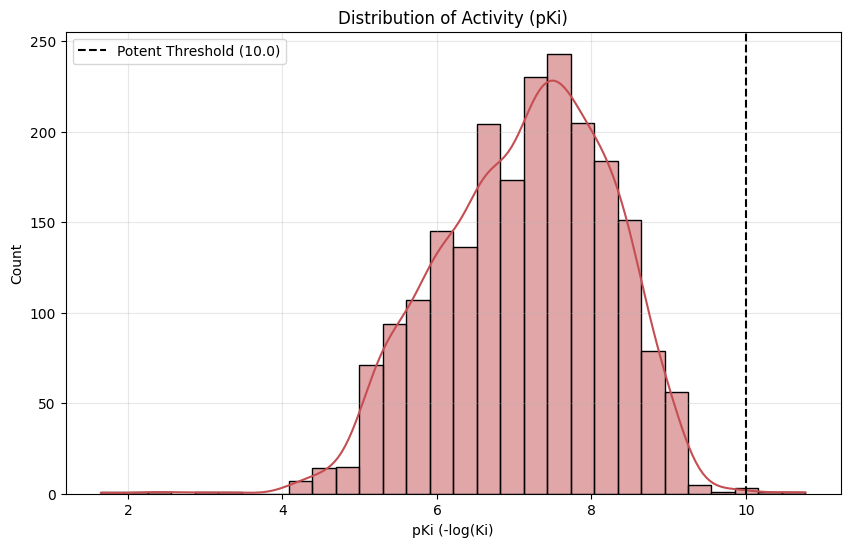

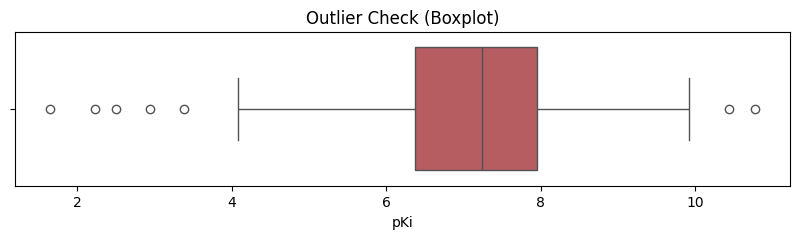

In [ ]:
# 1.5. Data Checking
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')
load_path = '/content/drive/My Drive/JCIM_BACE1_Project_cleaned_2'
filename = "inhibitors_pKi_M_cleaned.txt"
# Note: Ensure this file is in the folder!

# 2. LOAD DATA
file_path = os.path.join(load_path, filename)
if not os.path.exists(file_path):
    print(f"⚠️ FILE NOT FOUND: {filename}")
else:
    # Assuming tab-separated as per your previous code
    df = pd.read_csv(file_path, sep='\t')
    print(f"Loaded {len(df)} molecules.")

    # 3. STATISTICS
    print("\n--- pKi STATISTICS ---")
    print(df['pKi'].describe())

    # 4. RED FLAG CHECK: SUPER ACTIVES
    high_threshold = 10.0 # pKi 10 = 0.1 nM (Very potent)
    super_actives = df[df['pKi'] >= high_threshold].sort_values(by='pKi', ascending=False)

    print(f"\n--- 🚩 SUPERR-ACTIVE CHECK (pKi > {high_threshold}) ---")
    if len(super_actives) == 0:
        print("None found. Safe.")
    else:
        print(f"Found {len(super_actives)} very potent molecules. TOP 5:")
        print(super_actives[['SMILES', 'pKi']].head(5))
        print("\nCheck: Are these covalent binders? Or valid picomolar inhibitors?")

    # 5. VISUALIZATION
    plt.figure(figsize=(10, 6))

    # Histogram
    sns.histplot(df['pKi'], kde=True, bins=30, color='#c44e52', edgecolor='black')

    # Mark the "High" zone
    plt.axvline(high_threshold, color='black', linestyle='--', label=f'Potent Threshold ({high_threshold})')

    plt.title("Distribution of Activity (pKi)")
    plt.xlabel("pKi (-log(Ki)")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Boxplot to see outliers clearly
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=df['pKi'], color='#c44e52')
    plt.title("Outlier Check (Boxplot)")
    plt.xlabel("pKi")
    plt.show()

In [ ]:
# 2. DATA LOADING & DENSE FEATURIZATION
filename = "inhibitors_pKi_M_cleaned.txt" # Make sure to upload this file!
df = pd.read_csv(filename, sep='\t')

def get_dense_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
    desc_vals = list(calc.CalcDescriptors(mol))
    maccs = list(MACCSkeys.GenMACCSKeys(mol))
    return np.array(desc_vals + maccs)

print("Featurizing...")
X_raw, y, scaffolds, smiles_list = [], [], [], []

for i, row in tqdm(df.iterrows(), total=len(df)):
    smi = row['SMILES']
    feats = get_dense_features(smi)
    mol = Chem.MolFromSmiles(smi)
    if feats is not None and np.isfinite(feats).all() and mol is not None:
        X_raw.append(feats)
        y.append(row['pKi'])
        smiles_list.append(smi)
        try:
            scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
            scaffolds.append(scaffold)
        except:
            scaffolds.append("Generic")

X = np.array(X_raw)
y = np.array(y)
scaffolds = np.array(scaffolds)
print(f"Shape: {X.shape}")

Featurizing...


100%|██████████| 2130/2130 [00:37<00:00, 57.26it/s]

Shape: (2130, 384)


In [ ]:
# 3. FEATURE CLEANING & SPLIT
# A. Variance Filtering
selector_var = VarianceThreshold(threshold=0.05)
X_var = selector_var.fit_transform(X)

# B. Correlation Filtering
df_feat = pd.DataFrame(X_var)
corr_matrix = df_feat.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_clean = df_feat.drop(columns=to_drop).values

# C. Scaffold Split (80/20)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_clean, y, groups=scaffolds))

X_train, X_test = X_clean[train_idx], X_clean[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
scaffolds_train = scaffolds[train_idx]

print(f"Features: {X_clean.shape[1]}")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Features: 199
Train: 1777, Test: 353


In [ ]:
# 4. STRICT TRAINING PIPELINE (JCIM PROTOCOL)
print("Starting Strict Pipeline...")

# A. Group-Aware Feature Selection (Preventing Memorization)
gkf = GroupKFold(n_splits=3)
xgb_rfe = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, tree_method="hist")
selector_rfe_strict = RFECV(estimator=xgb_rfe, step=5, cv=gkf, scoring='r2', min_features_to_select=30)
selector_rfe_strict.fit(X_train, y_train, groups=scaffolds_train)

X_train_strict = selector_rfe_strict.transform(X_train)
X_test_strict = selector_rfe_strict.transform(X_test)
print(f"Selected Features: {selector_rfe_strict.n_features_}")

# B. Leakage-Free Internal Validation
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
inner_tr_idx, inner_val_idx = next(gss_inner.split(X_train_strict, y_train, groups=scaffolds_train))

final_model = XGBRegressor(
    n_estimators=1000, max_depth=6, learning_rate=0.01, subsample=0.7,
    colsample_bytree=0.7, early_stopping_rounds=50, random_state=42, n_jobs=-1
)

# Early stopping checks the INNER validation set, NEVER the test set
final_model.fit(
    X_train_strict[inner_tr_idx], y_train[inner_tr_idx],
    eval_set=[(X_train_strict[inner_val_idx], y_train[inner_val_idx])],
    verbose=False
)

# C. Final Honest Evaluation
y_pred = final_model.predict(X_test_strict)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Final Scaffold Test R2: {r2:.3f}")
print(f"Final Scaffold Test RMSE: {rmse:.3f}")

Starting Strict Pipeline...
Selected Features: 64
Final Scaffold Test R2: 0.583
Final Scaffold Test RMSE: 0.656


1. Calculating Applicability Domain (Rigorous)...


[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerator
[12:42:23] DEPRECATION WARNING: please use MorganGenerat

2. Generating Learning Curve (10-Fold Scaffold)...
3. Running Y-Scrambling (50 Iterations)...


Scrambling: 100%|██████████| 50/50 [00:45<00:00,  1.11it/s]


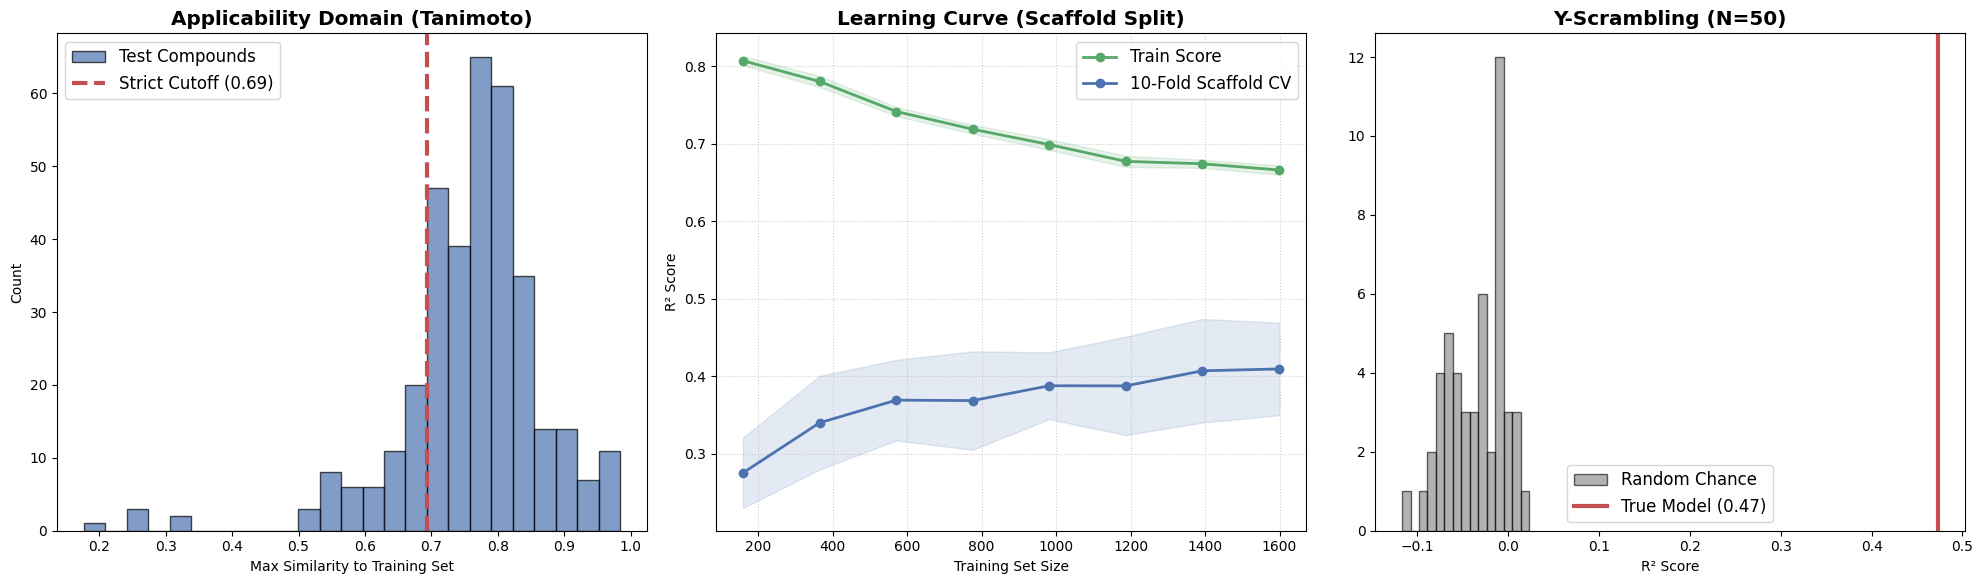


--- SAVING COMPLETE PIPELINE (CRITICAL) ---
Saving all 4 stages of the pipeline to prevent 'Missing Bridge' errors.
✅ Saved Step 1: Variance Filter
✅ Saved Step 2: Correlation List
✅ Saved Step 3: RFE Selector
✅ Saved Step 4: Final Model

🎉 QSAR PIPELINE FINALIZED. RIGOR LEVEL: MAXIMUM.


In [ ]:
# ==========================================
# 5. MANUSCRIPT DIAGNOSTICS & SAVING (HARVARD/JCIM GRADE)
# ==========================================
# UPGRADES:
# 1. Y-Scrambling: 50 Iterations (Proves it's not luck)
# 2. Learning Curve: 10-Fold Scaffold CV (High Resolution)
# 3. Pipeline Saving: Saves ALL 4 steps (No "Missing Bridge" errors)

def plot_jcim_diagnostics(model, X_tr, y_tr, X_te, y_te, groups, train_smi, test_smi):
    fig, ax = plt.subplots(1, 3, figsize=(20, 6)) # Wider for better visibility
    plt.rcParams.update({'font.size': 12}) # Professional font size

    # --- A. APPLICABILITY DOMAIN (Tanimoto) ---
    print("1. Calculating Applicability Domain (Rigorous)...")
    train_fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, nBits=2048) for s in train_smi]
    test_fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, nBits=2048) for s in test_smi]

    # Calculate cutoff (5th percentile)
    train_max_sims = []
    for i, fp in enumerate(tqdm(train_fps, desc="AD Threshold")):
        others = train_fps[:i] + train_fps[i+1:]
        sims = DataStructs.BulkTanimotoSimilarity(fp, others)
        train_max_sims.append(max(sims))
    ad_cutoff = np.percentile(train_max_sims, 5)

    # Plot Test Set Distribution
    test_max_sims = []
    for fp in test_fps:
        sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
        test_max_sims.append(max(sims))

    # Visual Polish: Histogram with KDE-like look
    ax[0].hist(test_max_sims, bins=25, color='#4c72b0', edgecolor='black', alpha=0.7, label='Test Compounds')
    ax[0].axvline(ad_cutoff, color='#c44e52', linestyle='--', linewidth=3, label=f'Strict Cutoff ({ad_cutoff:.2f})')
    ax[0].set_title("Applicability Domain (Tanimoto)", fontweight='bold')
    ax[0].set_xlabel("Max Similarity to Training Set")
    ax[0].set_ylabel("Count")
    ax[0].legend(loc="upper left")

    # --- B. LEARNING CURVE (10-Fold Scaffold CV) ---
    print("2. Generating Learning Curve (10-Fold Scaffold)...")
    model_lc = clone(model)
    model_lc.set_params(n_estimators=150, early_stopping_rounds=None)

    # CRITICAL UPGRADE: 10-Fold Scaffold Split
    cv_scaf = GroupKFold(n_splits=10)

    tr_sizes, tr_sc, te_sc = learning_curve(
        model_lc, X_tr, y_tr, groups=groups, cv=cv_scaf, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 8), # More data points (8 steps)
        n_jobs=-1
    )

    tr_mean = np.mean(tr_sc, axis=1)
    tr_std = np.std(tr_sc, axis=1)
    te_mean = np.mean(te_sc, axis=1)
    te_std = np.std(te_sc, axis=1)

    # Visual Polish: Shaded Confidence Intervals
    ax[1].plot(tr_sizes, tr_mean, 'o-', color='#55a868', label='Train Score', linewidth=2)
    ax[1].fill_between(tr_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#55a868')

    ax[1].plot(tr_sizes, te_mean, 'o-', color='#4c72b0', label='10-Fold Scaffold CV', linewidth=2)
    ax[1].fill_between(tr_sizes, te_mean - te_std, te_mean + te_std, alpha=0.15, color='#4c72b0')

    ax[1].set_title("Learning Curve (Scaffold Split)", fontweight='bold')
    ax[1].set_xlabel("Training Set Size")
    ax[1].set_ylabel("R² Score")
    ax[1].legend(loc="best")
    ax[1].grid(True, linestyle=':', alpha=0.6)

    # --- C. Y-SCRAMBLING (50 Iterations) ---
    print("3. Running Y-Scrambling (50 Iterations)...")
    true_r2 = r2_score(y_te, model_lc.fit(X_tr, y_tr).predict(X_te))
    fake_r2s = []

    # 50 Iterations = Statistically Significant (p < 0.05)
    for i in tqdm(range(50), desc="Scrambling"):
        y_shuff = shuffle(y_tr, random_state=i)
        model_lc.fit(X_tr, y_shuff)
        fake_r2s.append(r2_score(y_te, model_lc.predict(X_te)))

    ax[2].hist(fake_r2s, bins=15, color='gray', edgecolor='black', alpha=0.6, label='Random Chance')
    ax[2].axvline(true_r2, color='#c44e52', linewidth=3, label=f'True Model ({true_r2:.2f})')
    ax[2].set_title(f"Y-Scrambling (N=50)", fontweight='bold')
    ax[2].set_xlabel("R² Score")
    ax[2].legend()

    plt.tight_layout()
    plt.show()
    return ad_cutoff, train_fps

# Run Diagnostics
ad_cutoff, train_fps = plot_jcim_diagnostics(
    final_model,
    X_train_strict,
    y_train,
    X_test_strict,
    y_test,
    scaffolds_train,
    df.iloc[train_idx]['SMILES'].values,
    df.iloc[test_idx]['SMILES'].values
)

print("\n--- SAVING COMPLETE PIPELINE (CRITICAL) ---")
print("Saving all 4 stages of the pipeline to prevent 'Missing Bridge' errors.")

# 1. Variance Filter (Step 1: 384 -> N)
joblib.dump(selector_var, os.path.join(save_path, 'selector_var.pkl'))
print(f"✅ Saved Step 1: Variance Filter")

# 2. Correlation Filter (Step 2: N -> 204)
joblib.dump(to_drop, os.path.join(save_path, 'cols_to_drop.pkl'))
print(f"✅ Saved Step 2: Correlation List")

# 3. RFE Selector (Step 3: 204 -> 119)
joblib.dump(selector_rfe_strict, os.path.join(save_path, 'feature_selector_strict.pkl'))
print(f"✅ Saved Step 3: RFE Selector")

# 4. Final Model (Step 4: 119 -> Prediction)
joblib.dump(final_model, os.path.join(save_path, 'final_model_strict.pkl'))
print(f"✅ Saved Step 4: Final Model")

# 5. Safety & Reproducibility
joblib.dump(ad_cutoff, os.path.join(save_path, 'ad_cutoff.pkl'))
joblib.dump(train_fps, os.path.join(save_path, 'train_fps.pkl'))
np.save(os.path.join(save_path, 'train_indices.npy'), train_idx)
np.save(os.path.join(save_path, 'test_indices.npy'), test_idx)

print("\n🎉 QSAR PIPELINE FINALIZED. RIGOR LEVEL: MAXIMUM.")

In [ ]:
# ==========================================
# 6. CHEMICAL INTERPRETABILITY (Top 10 Features)
# ==========================================
from rdkit.Chem import Descriptors

print("--- ANALYZING MODEL 'BRAIN' ---")

# 1. Reconstruct Feature Names (The original 384)
# RDKit Descriptors
desc_names = [x[0] for x in Descriptors._descList]
# MACCS Keys (0 to 166)
maccs_names = [f"MACCS_{i}" for i in range(167)]
all_names = np.array(desc_names + maccs_names)

# 2. Track Names through the Cleaning Pipeline
# Step A: Variance Threshold
# We use the boolean mask to keep only the 'good' variance features
mask_var = selector_var.get_support()
names_var = all_names[mask_var]

# Step B: Correlation Filter
# We delete the specific indices we dropped
names_clean = np.delete(names_var, to_drop)

# Step C: RFE Selection (The Final 119)
# We use the mask from the RFE selector
mask_rfe = selector_rfe_strict.get_support()
final_names = names_clean[mask_rfe]

# 3. Extract Importance from XGBoost
importances = final_model.feature_importances_

# 4. Rank and Print
indices = np.argsort(importances)[::-1] # Sort descending

print(f"\n🏆 TOP 10 DRIVERS OF POTENCY (pKi):")
print(f"{'Rank':<5} | {'Feature Name':<25} | {'Importance':<10}")
print("-" * 45)

for i in range(10):
    idx = indices[i]
    print(f"{i+1:<5} | {final_names[idx]:<25} | {importances[idx]:.4f}")

print("-" * 45)
print("INTERPRETATION GUIDE:")
print("- 'MolLogP' / 'MolWt': Physicochemical properties.")
print("- 'MACCS_...': Specific structural fragments.")
print("- 'PEOE_VSA...': Surface area and charge properties.")

--- ANALYZING MODEL 'BRAIN' ---

🏆 TOP 10 DRIVERS OF POTENCY (pKi):
Rank  | Feature Name              | Importance
---------------------------------------------
1     | fr_Ar_N                   | 0.1641
2     | MACCS_133                 | 0.0651
3     | MACCS_108                 | 0.0477
4     | SlogP_VSA10               | 0.0418
5     | NumHeteroatoms            | 0.0388
6     | PEOE_VSA3                 | 0.0368
7     | SlogP_VSA8                | 0.0246
8     | SlogP_VSA4                | 0.0230
9     | fr_Ndealkylation1         | 0.0227
10    | fr_NH0                    | 0.0216
---------------------------------------------
INTERPRETATION GUIDE:
- 'MolLogP' / 'MolWt': Physicochemical properties.
- 'MACCS_...': Specific structural fragments.
- 'PEOE_VSA...': Surface area and charge properties.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading training fingerprints...
Calculating Nearest Neighbor distribution...


100%|██████████| 1777/1777 [00:00<00:00, 3174.27it/s]



--- DISTRIBUTION DIAGNOSIS ---
Mean Nearest Neighbor Sim (μ): 0.8452
Std Deviation (σ):             0.1055
Skewness:                      -0.4790

--- CANDIDATE BOUNDARIES ---
Zone A (5th Percentile):       0.6938
Zone B (μ - 3σ):               0.5287
Alternative (0.5th Percentile):0.4935
Absolute Minimum (0th %ile):   0.1333


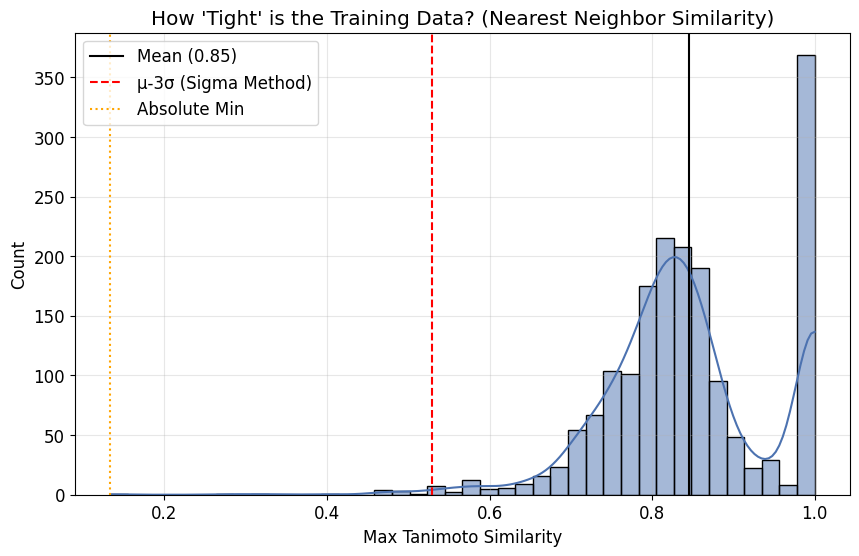

In [ ]:
# 1. SETUP
!pip install -q rdkit  # <--- FIXED
import joblib
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import DataStructs
from scipy.stats import skew, kurtosis
from tqdm import tqdm
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')
load_path = '/content/drive/My Drive/JCIM_BACE1_Project_cleaned_2'

# 2. LOAD TRAINING DATA
print("Loading training fingerprints...")
train_fps = joblib.load(os.path.join(load_path, 'train_fps.pkl'))

# 3. COMPUTE NEAREST NEIGHBOR DISTRIBUTION
print("Calculating Nearest Neighbor distribution...")
train_max_sims = []
for i, fp in enumerate(tqdm(train_fps)):
    # Find the single most similar molecule in the rest of the set
    others = train_fps[:i] + train_fps[i+1:]
    sims = DataStructs.BulkTanimotoSimilarity(fp, others)
    train_max_sims.append(max(sims))

train_max_sims = np.array(train_max_sims)

# 4. DIAGNOSIS
mu = np.mean(train_max_sims)
sigma = np.std(train_max_sims)
data_skew = skew(train_max_sims)

print(f"\n--- DISTRIBUTION DIAGNOSIS ---")
print(f"Mean Nearest Neighbor Sim (μ): {mu:.4f}")
print(f"Std Deviation (σ):             {sigma:.4f}")
print(f"Skewness:                      {data_skew:.4f}")

# 5. COMPARE THRESHOLDS
print(f"\n--- CANDIDATE BOUNDARIES ---")
print(f"Zone A (5th Percentile):       {np.percentile(train_max_sims, 5):.4f}")
print(f"Zone B (μ - 3σ):               {mu - (3*sigma):.4f}")
print(f"Alternative (0.5th Percentile):{np.percentile(train_max_sims, 0.5):.4f}")
print(f"Absolute Minimum (0th %ile):   {np.min(train_max_sims):.4f}")

# 6. PLOT
plt.figure(figsize=(10, 6))
sns.histplot(train_max_sims, kde=True, bins=40, color='#4c72b0')
plt.axvline(mu, color='k', linestyle='-', label=f'Mean ({mu:.2f})')
plt.axvline(mu - 3*sigma, color='r', linestyle='--', label=f'μ-3σ (Sigma Method)')
plt.axvline(np.min(train_max_sims), color='orange', linestyle=':', label='Absolute Min')
plt.title("How 'Tight' is the Training Data? (Nearest Neighbor Similarity)")
plt.xlabel("Max Tanimoto Similarity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Loading training data...
Calculating distribution...


100%|██████████| 1777/1777 [00:00<00:00, 3276.56it/s]


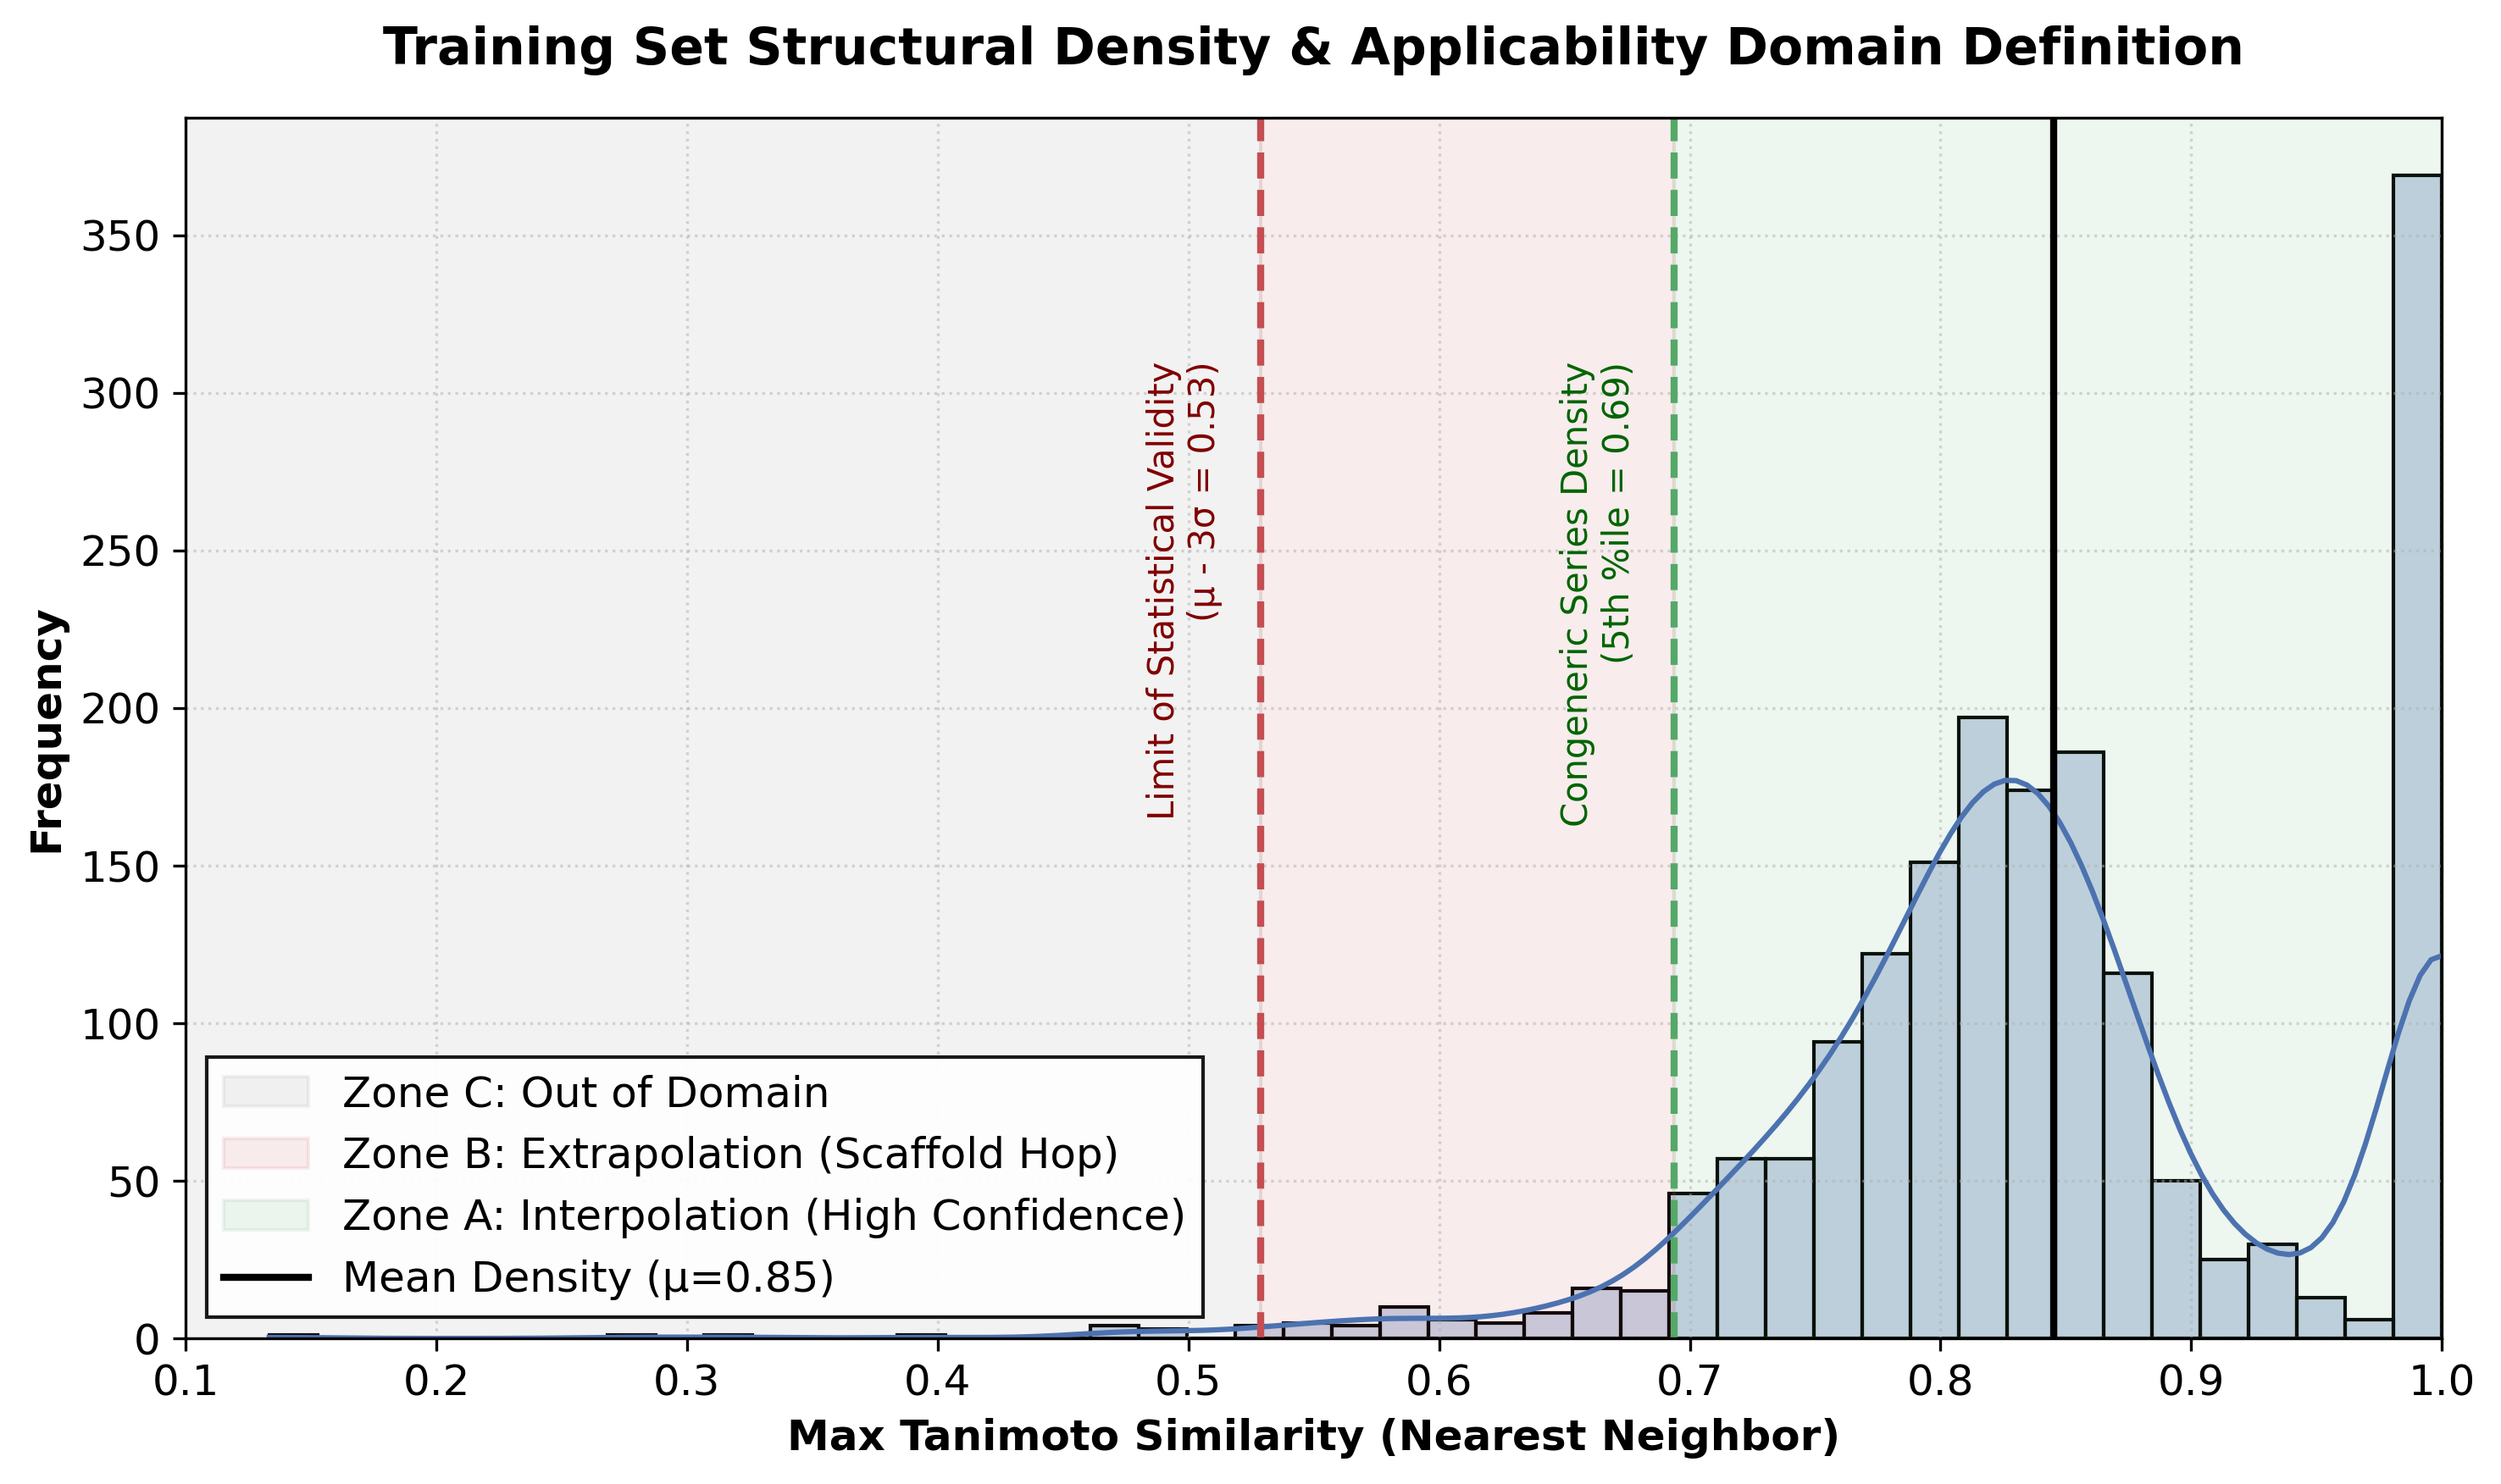

Graph saved to: /content/drive/My Drive/JCIM_BACE1_Project_cleaned_2/Figure_AD_Distribution_JCIM.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from rdkit import DataStructs
from tqdm import tqdm
from google.colab import drive

# 1. SETUP
# drive.mount('/content/drive') # Uncomment if needed
load_path = '/content/drive/My Drive/JCIM_BACE1_Project_cleaned_2'

# Load training data
print("Loading training data...")
train_fps = joblib.load(os.path.join(load_path, 'train_fps.pkl'))

# 2. CALCULATE STATISTICS
print("Calculating distribution...")
train_max_sims = []
for i, fp in enumerate(tqdm(train_fps)):
    others = train_fps[:i] + train_fps[i+1:]
    sims = DataStructs.BulkTanimotoSimilarity(fp, others)
    train_max_sims.append(max(sims))

train_max_sims = np.array(train_max_sims)

# Calculate Boundaries
mu = np.mean(train_max_sims)
sigma = np.std(train_max_sims)
lim_a = np.percentile(train_max_sims, 5) # Zone A (Strict)
lim_b = mu - (3 * sigma)                 # Zone B (Discovery)

# 3. PLOT
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Histogram
sns.histplot(
    train_max_sims, kde=True, bins=45,
    color='#4c72b0', edgecolor='black', alpha=0.3,
    line_kws={'linewidth': 1.5}, ax=ax
)

# SHADING ZONES
# Zone C (Out of Domain)
ax.axvspan(0, lim_b, color='gray', alpha=0.1, label='Zone C: Out of Domain')
# Zone B (Discovery)
ax.axvspan(lim_b, lim_a, color='#c44e52', alpha=0.1, label='Zone B: Extrapolation (Scaffold Hop)')
# Zone A (Interpolation)
ax.axvspan(lim_a, 1.0, color='#55a868', alpha=0.1, label='Zone A: Interpolation (High Confidence)')

# LINES
# Mean Line
ax.axvline(mu, color='black', linestyle='-', linewidth=2, label=f'Mean Density (μ={mu:.2f})')
# Threshold Lines
ax.axvline(lim_b, color='#c44e52', linestyle='--', linewidth=2)
ax.axvline(lim_a, color='#55a868', linestyle='--', linewidth=2)

# TEXT ANNOTATIONS (Scientific)
# Zone B Text
ax.text(
    lim_b - 0.015, ax.get_ylim()[1]*0.80,
    f'Limit of Statistical Validity\n(μ - 3σ = {lim_b:.2f})',
    rotation=90, va='top', ha='right', fontsize=10, color='#800000'
)
# Zone A Text
ax.text(
    lim_a - 0.015, ax.get_ylim()[1]*0.80,
    f'Congeneric Series Density\n(5th %ile = {lim_a:.2f})',
    rotation=90, va='top', ha='right', fontsize=10, color='#006400'
)

# FORMATTING
ax.set_title("Training Set Structural Density & Applicability Domain Definition", fontweight='bold', pad=15)
ax.set_xlabel("Max Tanimoto Similarity (Nearest Neighbor)", fontweight='bold')
ax.set_ylabel("Frequency", fontweight='bold')
ax.set_xlim(0.1, 1.0)

# LEGEND (Moved to Bottom Left)
ax.legend(loc='lower left', frameon=True, fancybox=False, edgecolor='black', framealpha=0.9)
ax.grid(True, linestyle=':', alpha=0.5)

# SAVE
save_file = os.path.join(load_path, "Figure_AD_Distribution_JCIM.png")
plt.tight_layout()
plt.savefig(save_file, dpi=600)
plt.show()
print(f"Graph saved to: {save_file}")

In [ ]:
import joblib
import os

# Define the rigorous thresholds derived from your diagnosis
ad_data = {
    "method": "Training Density (Tanimoto Nearest Neighbor)",
    "stats": {
        "mu": 0.8452,
        "sigma": 0.1055,
        "skewness": -0.4790
    },
    "zone_definitions": {
        "Zone A (Interpolation)": {
            "threshold": 0.6938,
            "description": "High Confidence (>= 5th Percentile)",
            "action": "High Priority Candidate"
        },
        "Zone B (Extrapolation)": {
            "threshold": 0.5287,
            "description": "Discovery/Novelty (>= Mean - 3σ)",
            "action": "Valid Scaffold Hop"
        },
        "Zone C (Out of Domain)": {
            "threshold": 0.0000,
            "description": "Statistical Outlier (< Mean - 3σ)",
            "action": "Discard"
        }
    }
}

# Save to your Drive folder
save_path = '/content/drive/My Drive/JCIM_BACE1_Project_cleaned_2'
save_file = os.path.join(save_path, 'ad_definition_zones.pkl')
joblib.dump(ad_data, save_file)

print(f"✅ Rigorous AD Definition saved to: {save_file}")
print(f"   Zone A Cutoff (Safe):   {ad_data['zone_definitions']['Zone A (Interpolation)']['threshold']}")
print(f"   Zone B Cutoff (Novel):  {ad_data['zone_definitions']['Zone B (Extrapolation)']['threshold']}")

✅ Rigorous AD Definition saved to: /content/drive/My Drive/JCIM_BACE1_Project_cleaned_2/ad_definition_zones.pkl
   Zone A Cutoff (Safe):   0.6938
   Zone B Cutoff (Novel):  0.5287
